In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/blast-fragmentation-analysis"
os.makedirs(f"{project_path}/data", exist_ok=True)
os.makedirs(f"{project_path}/outputs", exist_ok=True)

print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/blast-fragmentation-analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f"{project_path}/data/hudaverdi_blast_fragmentation_dataset (1).csv")



In [ ]:
df.shape

(110, 15)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   blast_id                       110 non-null    object 
 1   mine_name                      110 non-null    object 
 2   country                        110 non-null    object 
 3   rock_type                      110 non-null    object 
 4   mine_type                      110 non-null    object 
 5   cluster_group                  110 non-null    object 
 6   spacing_to_burden_ratio        110 non-null    float64
 7   bench_height_to_burden_ratio   110 non-null    float64
 8   burden_to_hole_diameter_ratio  110 non-null    float64
 9   stemming_to_burden_ratio       110 non-null    float64
 10  powder_factor_kg_m3            110 non-null    float64
 11  insitu_block_size_m            110 non-null    float64
 12  modulus_of_elasticity_gpa      110 non-null    flo

In [ ]:
df.describe()

,spacing_to_burden_ratio,bench_height_to_burden_ratio,burden_to_hole_diameter_ratio,stemming_to_burden_ratio,powder_factor_kg_m3,insitu_block_size_m,modulus_of_elasticity_gpa,mean_fragment_size_m,mean_fragment_size_cm
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,1.185000,3.338455,27.414909,1.258455,0.539273,1.092455,29.165455,0.299455,29.945455
std,0.114241,1.602141,4.942791,0.672038,0.238742,0.529778,17.824318,0.184400,18.440003
min,1.000000,1.330000,17.980000,0.500000,0.220000,0.020000,9.570000,0.020000,2.000000
25%,1.130000,2.070000,24.720000,0.830000,0.352500,0.692500,15.000000,0.170000,17.000000
50%,1.200000,2.815000,27.270000,1.110000,0.480000,1.030000,16.900000,0.230000,23.000000
75%,1.247500,4.687500,30.300000,1.400000,0.682500,1.522500,45.000000,0.395000,39.500000
max,1.750000,6.820000,39.470000,4.670000,1.260000,2.350000,60.000000,0.960000,96.000000


In [ ]:
df.isnull().sum()

,0
blast_id,0
mine_name,0
country,0
rock_type,0
mine_type,0
cluster_group,0
spacing_to_burden_ratio,0
bench_height_to_burden_ratio,0
burden_to_hole_diameter_ratio,0
stemming_to_burden_ratio,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,blast_id,mine_name,country,rock_type,mine_type,cluster_group,spacing_to_burden_ratio,bench_height_to_burden_ratio,burden_to_hole_diameter_ratio,stemming_to_burden_ratio,powder_factor_kg_m3,insitu_block_size_m,modulus_of_elasticity_gpa,mean_fragment_size_m,mean_fragment_size_cm
0,En1,Enusa Mine,Spain,"Uranium ore (schistose, folded)",Open-pit,Group 1 (high elastic modulus),1.24,1.33,27.27,0.78,0.48,0.58,60.0,0.37,37.0
1,En2,Enusa Mine,Spain,"Uranium ore (schistose, folded)",Open-pit,Group 1 (high elastic modulus),1.24,1.33,27.27,0.78,0.48,0.58,60.0,0.37,37.0
2,En3,Enusa Mine,Spain,"Uranium ore (schistose, folded)",Open-pit,Group 1 (high elastic modulus),1.24,1.33,27.27,0.78,0.48,1.08,60.0,0.33,33.0
3,En4,Enusa Mine,Spain,"Uranium ore (schistose, folded)",Open-pit,Group 1 (high elastic modulus),1.24,1.33,27.27,0.78,0.48,1.11,60.0,0.42,42.0
4,En5,Enusa Mine,Spain,"Uranium ore (schistose, folded)",Open-pit,Group 1 (high elastic modulus),1.24,1.33,27.27,0.78,0.48,1.08,60.0,0.46,46.0


In [ ]:
analysis_df = df[
    df['cluster_group'] != 'Validation set (Table VIII)'
]

validation_df = df[
    df['cluster_group'] == 'Validation set (Table VIII)'
]

print("Analysis data:", len(analysis_df))
print("Validation data:", len(validation_df))

Analysis data: 97
Validation data: 13


In [ ]:
df['mean_fragment_size_cm'].describe()

,mean_fragment_size_cm
count,110.000000
mean,29.945455
std,18.440003
min,2.000000
25%,17.000000
50%,23.000000
75%,39.500000
max,96.000000


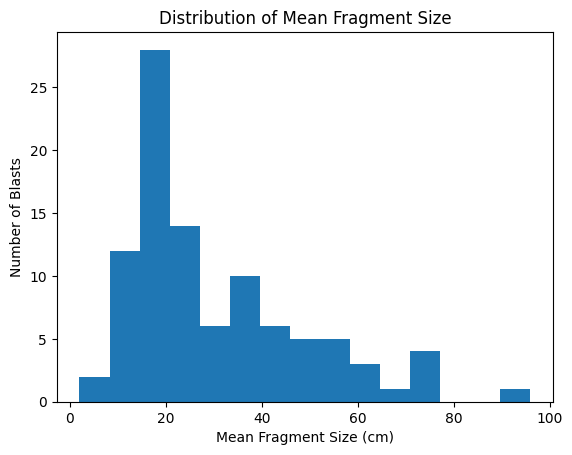

In [ ]:
import matplotlib.pyplot as plt

plt.hist(analysis_df['mean_fragment_size_cm'], bins=15)

plt.xlabel('Mean Fragment Size (cm)')
plt.ylabel('Number of Blasts')
plt.title('Distribution of Mean Fragment Size')

plt.show()

In [ ]:
analysis_df[
    [
        'spacing_to_burden_ratio',
        'bench_height_to_burden_ratio',
        'burden_to_hole_diameter_ratio',
        'stemming_to_burden_ratio',
        'powder_factor_kg_m3',
        'insitu_block_size_m',
        'modulus_of_elasticity_gpa',
        'mean_fragment_size_cm'
    ]
].corr()['mean_fragment_size_cm'].sort_values()

,mean_fragment_size_cm
powder_factor_kg_m3,-0.407042
bench_height_to_burden_ratio,-0.143635
burden_to_hole_diameter_ratio,-0.011581
spacing_to_burden_ratio,0.183430
stemming_to_burden_ratio,0.390677
insitu_block_size_m,0.404539
modulus_of_elasticity_gpa,0.526183
mean_fragment_size_cm,1.000000


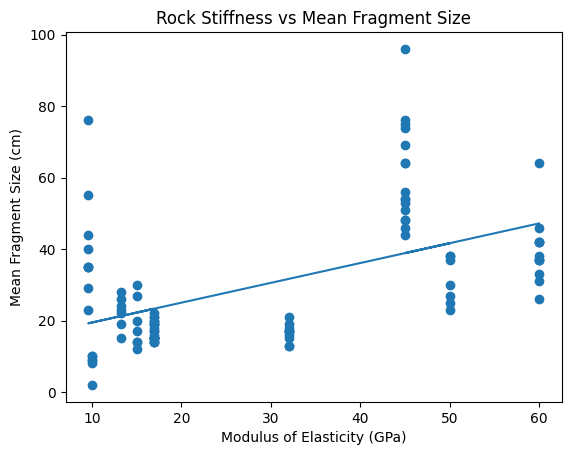

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = analysis_df['modulus_of_elasticity_gpa']
y = analysis_df['mean_fragment_size_cm']

plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b)

plt.xlabel('Modulus of Elasticity (GPa)')
plt.ylabel('Mean Fragment Size (cm)')
plt.title('Rock Stiffness vs Mean Fragment Size')

plt.show()

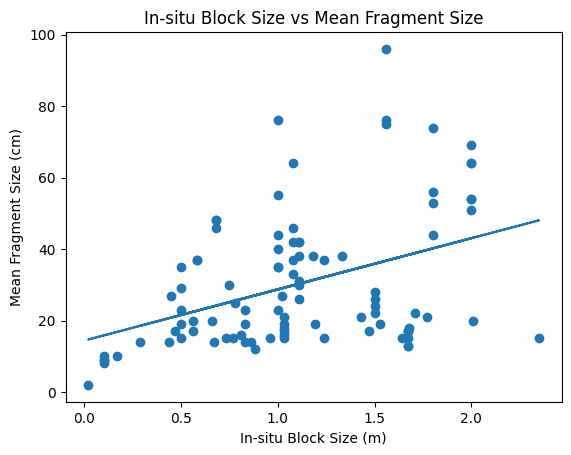

In [ ]:
x = analysis_df['insitu_block_size_m']
y = analysis_df['mean_fragment_size_cm']

plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b)

plt.xlabel('In-situ Block Size (m)')
plt.ylabel('Mean Fragment Size (cm)')
plt.title('In-situ Block Size vs Mean Fragment Size')

plt.show()

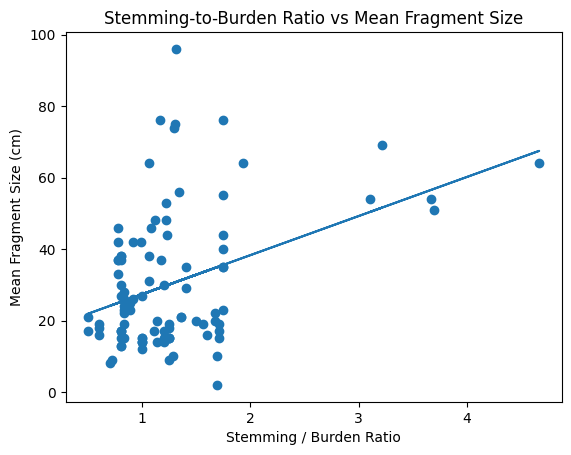

In [ ]:
x = analysis_df['stemming_to_burden_ratio']
y = analysis_df['mean_fragment_size_cm']

plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b)

plt.xlabel('Stemming / Burden Ratio')
plt.ylabel('Mean Fragment Size (cm)')
plt.title('Stemming-to-Burden Ratio vs Mean Fragment Size')

plt.show()

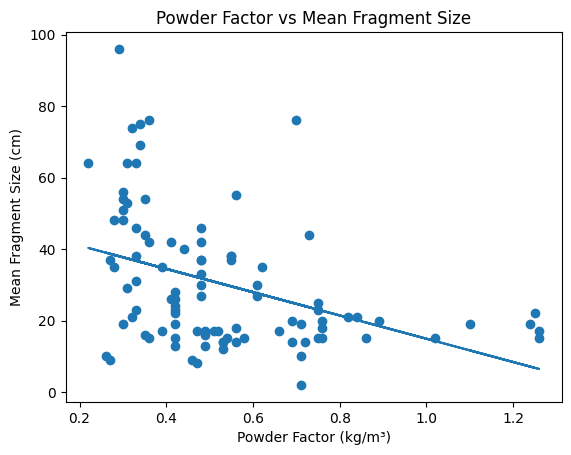

In [ ]:
x = analysis_df['powder_factor_kg_m3']
y = analysis_df['mean_fragment_size_cm']

plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b)

plt.xlabel('Powder Factor (kg/m³)')
plt.ylabel('Mean Fragment Size (cm)')
plt.title('Powder Factor vs Mean Fragment Size')

plt.show()

In [ ]:
analysis_df['cluster_group'].value_counts()

,count
cluster_group,
Group 2 (low elastic modulus),62
Group 1 (high elastic modulus),35


In [ ]:
df.groupby('cluster_group')['mean_fragment_size_cm'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster_group,,,,,,,,
Group 1 (high elastic modulus),35.0,47.571429,16.889408,23.0,37.0,44.0,55.0,96.0
Group 2 (low elastic modulus),62.0,20.483871,11.421495,2.0,15.0,17.0,22.0,76.0
Validation set (Table VIII),13.0,27.615385,15.580642,8.0,18.0,21.0,35.0,64.0


In [ ]:
df.groupby('cluster_group')[
    [
        'powder_factor_kg_m3',
        'insitu_block_size_m',
        'modulus_of_elasticity_gpa',
        'mean_fragment_size_cm'
    ]
].mean()

,powder_factor_kg_m3,insitu_block_size_m,modulus_of_elasticity_gpa,mean_fragment_size_cm
cluster_group,,,,
Group 1 (high elastic modulus),0.406000,1.290286,51.142857,47.571429
Group 2 (low elastic modulus),0.598710,1.003065,17.220645,20.483871
Validation set (Table VIII),0.614615,0.986154,26.963077,27.615385


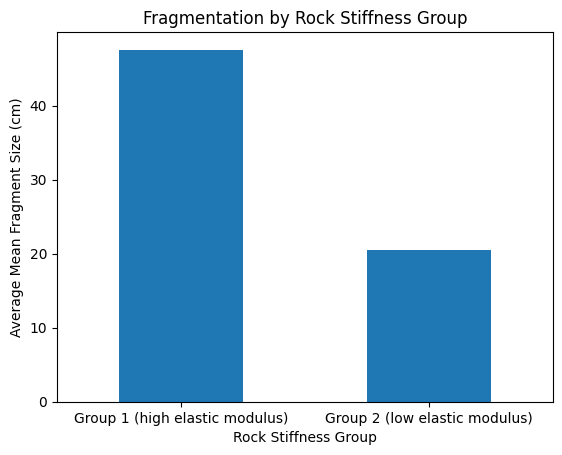

In [ ]:
stiffness_df = df[
    df['cluster_group'].isin([
        'Group 1 (high elastic modulus)',
        'Group 2 (low elastic modulus)'
    ])
]

group_means = stiffness_df.groupby(
    'cluster_group'
)['mean_fragment_size_cm'].mean()

group_means.plot(kind='bar')

plt.xlabel('Rock Stiffness Group')
plt.ylabel('Average Mean Fragment Size (cm)')
plt.title('Fragmentation by Rock Stiffness Group')

plt.xticks(rotation=0)
plt.show()

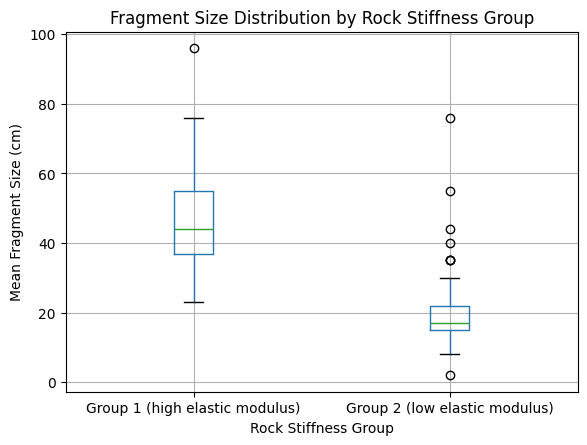

In [ ]:
stiffness_df.boxplot(
    column='mean_fragment_size_cm',
    by='cluster_group'
)

plt.xlabel('Rock Stiffness Group')
plt.ylabel('Mean Fragment Size (cm)')
plt.title('Fragment Size Distribution by Rock Stiffness Group')

plt.suptitle('')
plt.xticks(rotation=0)

plt.show()

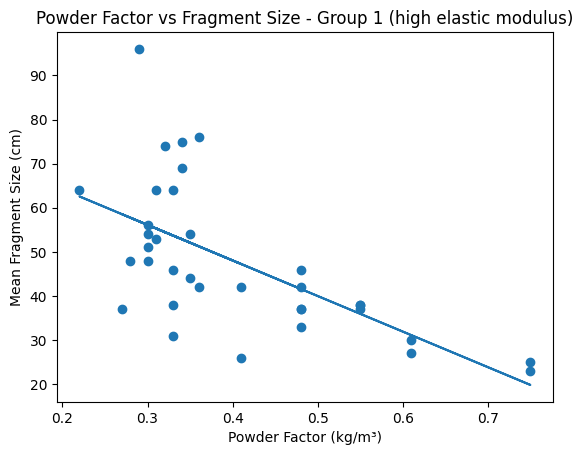

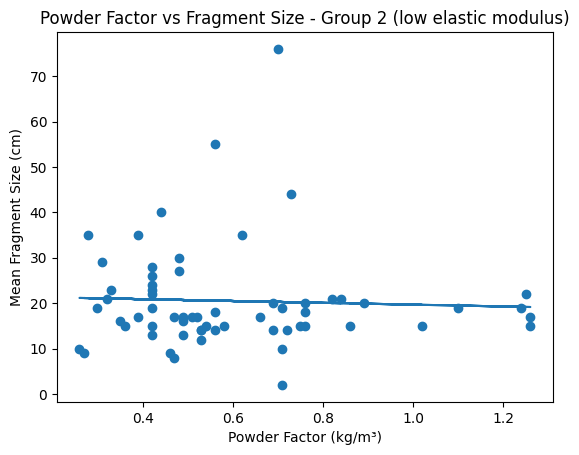

In [ ]:
for group in [
    'Group 1 (high elastic modulus)',
    'Group 2 (low elastic modulus)'
]:

    data = df[df['cluster_group'] == group]

    x = data['powder_factor_kg_m3']
    y = data['mean_fragment_size_cm']

    plt.scatter(x, y)

    m, b = np.polyfit(x, y, 1)

    plt.plot(x, m*x + b)

    plt.xlabel('Powder Factor (kg/m³)')
    plt.ylabel('Mean Fragment Size (cm)')
    plt.title(f'Powder Factor vs Fragment Size - {group}')

    plt.show()

In [ ]:
for group in [
    'Group 1 (high elastic modulus)',
    'Group 2 (low elastic modulus)'
]:

    data = df[df['cluster_group'] == group]

    correlation = data['powder_factor_kg_m3'].corr(
        data['mean_fragment_size_cm']
    )

    print(group, ":", round(correlation, 3))

Group 1 (high elastic modulus) : -0.637
Group 2 (low elastic modulus) : -0.044


In [ ]:
df.groupby('cluster_group')[
    [
        'spacing_to_burden_ratio',
        'bench_height_to_burden_ratio',
        'burden_to_hole_diameter_ratio',
        'stemming_to_burden_ratio',
        'powder_factor_kg_m3',
        'insitu_block_size_m',
        'modulus_of_elasticity_gpa',
        'mean_fragment_size_cm'
    ]
].mean()

,spacing_to_burden_ratio,bench_height_to_burden_ratio,burden_to_hole_diameter_ratio,stemming_to_burden_ratio,powder_factor_kg_m3,insitu_block_size_m,modulus_of_elasticity_gpa,mean_fragment_size_cm
cluster_group,,,,,,,,
Group 1 (high elastic modulus),1.171714,2.442857,28.548571,1.411714,0.406000,1.290286,51.142857,47.571429
Group 2 (low elastic modulus),1.198710,3.854516,26.681129,1.178710,0.598710,1.003065,17.220645,20.483871
Validation set (Table VIII),1.155385,3.288462,27.862308,1.226154,0.614615,0.986154,26.963077,27.615385


In [ ]:
analysis_df.groupby('mine_name')['mean_fragment_size_cm'].mean().sort_values()

,mean_fragment_size_cm
mine_name,
Miami Mine,8.000000
Mrica Quarry,16.636364
Akdaglar Quarry,17.090909
Ozmert Quarry,19.142857
Soma Basin Coal Mine,22.428571
Murgul Copper Mine,31.142857
Enusa Mine,39.583333
Dongri-Buzurg Mine,41.333333
Reocin Mine (Underground),59.333333


In [ ]:
analysis_df.groupby('rock_type')['mean_fragment_size_cm'].mean().sort_values()

,mean_fragment_size_cm
rock_type,
Pinal schist,8.000000
Andesite,16.636364
Sandstone (aggregate),17.586207
Coal,22.428571
Dacite / altered dacite (copper),31.142857
"Uranium ore (schistose, folded)",39.583333
Manganese ore (micaceous/muscovite schist),41.333333
Zinc ore,60.750000


In [ ]:
analysis_df.groupby('mine_type')['mean_fragment_size_cm'].mean().sort_values()

,mean_fragment_size_cm
mine_type,
Quarry,16.108696
Open-pit,40.844444
Underground,59.333333


In [ ]:
analysis_df['powder_factor_group'] = pd.qcut(
    analysis_df['powder_factor_kg_m3'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

/tmp/ipykernel_2452/1476915019.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df['powder_factor_group'] = pd.qcut(


In [ ]:
analysis_df['powder_factor_group'].value_counts()

,count
powder_factor_group,
Medium,33
Low,32
High,32


In [ ]:
analysis_df.groupby(
    'powder_factor_group',
    observed=True
)['mean_fragment_size_cm'].mean()

,mean_fragment_size_cm
powder_factor_group,
Low,44.156250
Medium,24.606061
High,22.187500


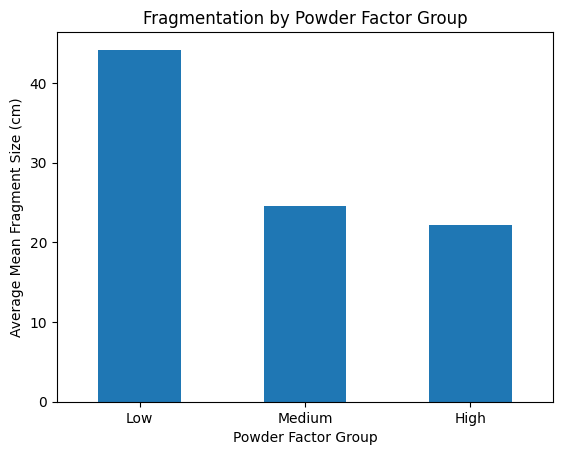

In [ ]:
analysis_df.groupby(
    'powder_factor_group',
    observed=True
)['mean_fragment_size_cm'].mean().plot(kind='bar')

plt.xlabel('Powder Factor Group')
plt.ylabel('Average Mean Fragment Size (cm)')
plt.title('Fragmentation by Powder Factor Group')

plt.xticks(rotation=0)
plt.show()


In [ ]:
analysis_df.groupby(
    ['cluster_group', 'powder_factor_group'],
    observed=True
)['mean_fragment_size_cm'].mean()

cluster_group                   powder_factor_group
Group 1 (high elastic modulus)  Low                    56.380952
                                Medium                 37.600000
                                High                   26.250000
Group 2 (low elastic modulus)   Low                    20.818182
                                Medium                 18.956522
                                High                   21.607143
Name: mean_fragment_size_cm, dtype: float64

In [ ]:
powder_stiffness = analysis_df.groupby(
    ['cluster_group', 'powder_factor_group'],
    observed=True
)['mean_fragment_size_cm'].mean().reset_index()

powder_stiffness

,cluster_group,powder_factor_group,mean_fragment_size_cm
0,Group 1 (high elastic modulus),Low,56.380952
1,Group 1 (high elastic modulus),Medium,37.600000
2,Group 1 (high elastic modulus),High,26.250000
3,Group 2 (low elastic modulus),Low,20.818182
4,Group 2 (low elastic modulus),Medium,18.956522
5,Group 2 (low elastic modulus),High,21.607143


In [ ]:
analysis_df.groupby('mine_name')['mean_fragment_size_cm'].mean().sort_values()

,mean_fragment_size_cm
mine_name,
Miami Mine,8.000000
Mrica Quarry,16.636364
Akdaglar Quarry,17.090909
Ozmert Quarry,19.142857
Soma Basin Coal Mine,22.428571
Murgul Copper Mine,31.142857
Enusa Mine,39.583333
Dongri-Buzurg Mine,41.333333
Reocin Mine (Underground),59.333333


In [ ]:
analysis_df.groupby('rock_type')['mean_fragment_size_cm'].mean().sort_values()

,mean_fragment_size_cm
rock_type,
Pinal schist,8.000000
Andesite,16.636364
Sandstone (aggregate),17.586207
Coal,22.428571
Dacite / altered dacite (copper),31.142857
"Uranium ore (schistose, folded)",39.583333
Manganese ore (micaceous/muscovite schist),41.333333
Zinc ore,60.750000


In [ ]:
analysis_df.groupby('mine_type')['mean_fragment_size_cm'].mean().sort_values()

,mean_fragment_size_cm
mine_type,
Quarry,16.108696
Open-pit,40.844444
Underground,59.333333


In [ ]:
analysis_df.groupby('mine_name').size().sort_values()

,0
mine_name,
Miami Mine,6
Reocin Mine (Underground),6
Ozmert Quarry,7
Murgul Copper Mine,7
Soma Basin Coal Mine,7
Dongri-Buzurg Mine,9
Reocin Mine,10
Mrica Quarry,11
Enusa Mine,12


In [ ]:
analysis_df.groupby('rock_type').size().sort_values()

,0
rock_type,
Pinal schist,6
Coal,7
Dacite / altered dacite (copper),7
Manganese ore (micaceous/muscovite schist),9
Andesite,11
"Uranium ore (schistose, folded)",12
Zinc ore,16
Sandstone (aggregate),29


In [ ]:
analysis_df.groupby('mine_type').size()

,0
mine_type,
Open-pit,45
Quarry,46
Underground,6


In [ ]:
correlation_summary = analysis_df[
    [
        'spacing_to_burden_ratio',
        'bench_height_to_burden_ratio',
        'burden_to_hole_diameter_ratio',
        'stemming_to_burden_ratio',
        'powder_factor_kg_m3',
        'insitu_block_size_m',
        'modulus_of_elasticity_gpa',
        'mean_fragment_size_cm'
    ]
].corr()['mean_fragment_size_cm'].sort_values()

correlation_summary

,mean_fragment_size_cm
powder_factor_kg_m3,-0.407042
bench_height_to_burden_ratio,-0.143635
burden_to_hole_diameter_ratio,-0.011581
spacing_to_burden_ratio,0.183430
stemming_to_burden_ratio,0.390677
insitu_block_size_m,0.404539
modulus_of_elasticity_gpa,0.526183
mean_fragment_size_cm,1.000000


In [64]:
analysis_df.to_csv('blast_analysis_final.csv', index=False)